In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,add_messages
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
#sys.path.insert(2, r'C:\Users\Dharmendra Vartika\LLM\langchain_document_loader')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from typing import TypedDict,Literal,Annotated
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults




In [2]:
class human(TypedDict):
    message :Annotated[list[BaseMessage],add_messages]
    # :str
    feedback :str
    comment:str
    


In [3]:
model_llm=ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

In [4]:
def chatbot_dharmendra(state:human):
    ques=state['message']
    result=model_llm.invoke(ques)
    #print ('tool_message',result.tool_calls)
    #state['tool_message']=result
    #state['result']=result.content
    state['message']=[result]
    #state['feeback']='good'
    return state
    

In [5]:
def approve(state:human):
    return state

In [6]:
def reject(state:human):
    comment= state['comment']
    #print ('comment is',comment)
    comment1=[HumanMessage(content=comment)]
    print ('comment is',comment)
    state['message']=state['message']+comment1
    msg=state['message']
    print ('msg ',msg)
    if comment1:


        result=model_llm.invoke(msg)
        state['message']=[result]
        return state
    else:
        return state

In [7]:
def human_feedback(state: human):
    print ('cool, you have reached human feedback stage')
    pass

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
def decision_check(state:human):
    print ('decision_check, you have reached  decision_check stage')
    review=state['feedback']
    if review=='Approve':
        return 'approve'
    elif review=='Reject':
        return 'reject'            
   
    #print ('tool_message',result.tool_calls)
    #state['tool_message']=result
    #state['result']=result
    

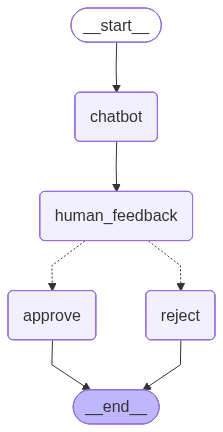

In [20]:
graph=StateGraph(human)
checkpointer = InMemorySaver()
graph.add_node('chatbot',chatbot_dharmendra)
graph.add_node('human_feedback',human_feedback)
graph.add_node('approve',approve)
graph.add_node('reject',reject)
graph.add_edge(START,'chatbot')
graph.add_edge('chatbot','human_feedback')
graph.add_conditional_edges('human_feedback',decision_check ,{'approve':'approve','reject':'reject'})

graph.add_edge('approve',END)
graph.add_edge('reject',END)
#workflow=graph.compile(checkpointer=checkpointer,interrupt_before=["human_feedback"])
workflow=graph.compile(checkpointer=checkpointer)
#workflow=graph.compile(checkpointer=checkpointer)
workflow

In [21]:
question ='What is cricket in 500 words'
config1 = {"configurable": {"thread_id": "12"}}
initial_stage={'message':question}
res=workflow.invoke(initial_stage,config=config1,interrupt_before=["human_feedback"])
#generator=workflow.stream(initial_stage,config=config1,stream_mode='values')
#for i in generator:
#    print (i)

In [22]:
 "__interrupt__" in res['message']

False

In [23]:
res

{'message': [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='da08b5f1-4a24-49e2-a7ea-05901bf17339'),
  AIMessage(content='Cricket is a popular sport that is played by millions of people around the world. It is a bat-and-ball game that is played between two teams of eleven players each. The game is played on a circular field with a rectangular pitch in the center. The objective of the game is for one team to score more runs than the other team.\n\nCricket has a long and rich history that dates back to the 16th century. It is believed to have originated in England and was first played by shepherds who used their crooks as bats and stones as balls. Over the years, the game evolved and became more organized, with rules and regulations being established to govern the game.\n\nCricket is played in various formats, with the most popular being Test cricket, One Day Internationals (ODIs), and Twenty20 (T20) cricket. Test cricket is the longes

In [24]:
state=workflow.get_state(config1)
state.next

('human_feedback',)

In [25]:
state

StateSnapshot(values={'message': [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='da08b5f1-4a24-49e2-a7ea-05901bf17339'), AIMessage(content='Cricket is a popular sport that is played by millions of people around the world. It is a bat-and-ball game that is played between two teams of eleven players each. The game is played on a circular field with a rectangular pitch in the center. The objective of the game is for one team to score more runs than the other team.\n\nCricket has a long and rich history that dates back to the 16th century. It is believed to have originated in England and was first played by shepherds who used their crooks as bats and stones as balls. Over the years, the game evolved and became more organized, with rules and regulations being established to govern the game.\n\nCricket is played in various formats, with the most popular being Test cricket, One Day Internationals (ODIs), and Twenty20 (T20) cricket. Test cr

In [101]:

workflow.update_state(config1, values={"feedback": "Reject","comment": "Explain me in 20 words only to a 5 years old"})
result1=workflow.invoke(None, config1)

cool, you have reached human feedback stage
decision_check, you have reached  decision_check stage
comment is Explain me in 20 words only to a 5 years old
msg  [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='0c4864b7-9cdd-408e-acdb-c4db565ca358'), AIMessage(content="Cricket is a popular sport that is played by millions of people around the world. It is a bat-and-ball game that is played between two teams of eleven players each. The game is played on a circular field with a rectangular pitch in the center. The objective of the game is for one team to score more runs than the other team.\n\nCricket has a long and rich history that dates back to the 16th century. It is believed to have originated in England and was first played by shepherds who used their crooks as bats and stones as balls. Over the years, the game evolved and became more organized, with rules and regulations being established to govern the game.\n\nCricket is played i

In [102]:
result1

{'message': [HumanMessage(content='What is cricket in 500 words', additional_kwargs={}, response_metadata={}, id='0c4864b7-9cdd-408e-acdb-c4db565ca358'),
  AIMessage(content="Cricket is a popular sport that is played by millions of people around the world. It is a bat-and-ball game that is played between two teams of eleven players each. The game is played on a circular field with a rectangular pitch in the center. The objective of the game is for one team to score more runs than the other team.\n\nCricket has a long and rich history that dates back to the 16th century. It is believed to have originated in England and was first played by shepherds who used their crooks as bats and stones as balls. Over the years, the game evolved and became more organized, with rules and regulations being established to govern the game.\n\nCricket is played in various formats, with the most popular being Test cricket, One Day Internationals (ODIs), and Twenty20 (T20) cricket. Test cricket is the oldest

In [261]:
workflow.update_state(config1, values={"feedack": "reject","comment": "Explain me in 50 words only to a 155 years old"})


{'configurable': {'thread_id': '13',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b6e75-90c0-6aae-8005-e2f2df6104a8'}}